# Network Spec Layer Smoke Test
This notebook validates declarative network specs and resolver integration.

## A. Imports

In [1]:
import sys
from pathlib import Path

# Locate the repository root by searching for extensions/scenario_api
cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'extensions' / 'scenario_api').exists()), None)
if repo_root is None:
    raise RuntimeError('Could not locate extensions/scenario_api from current working directory')

extensions_dir = repo_root / 'extensions'
if str(extensions_dir) not in sys.path:
    sys.path.insert(0, str(extensions_dir))

from scenario_api import *


## B. Create Example Specs

In [2]:
households = create_network_spec(
    name="households",
    kind="household",
    config={"population_size": 1000},
)

work = create_network_spec(
    name="work",
    kind="activity_structured",
    config={"mean_contacts": 10, "activation_prob": 0.5, "group": "working_age"},
)

community = create_network_spec(
    name="community",
    kind="activity_random",
    config={"mean_contacts": 4, "dispersion": 2},
)

specs = [households, work, community]
for spec in specs:
    print(network_spec_to_dict(spec))


{'name': 'households', 'kind': 'household', 'config': {'population_size': 1000}, 'metadata': {}}
{'name': 'work', 'kind': 'activity_structured', 'config': {'mean_contacts': 10, 'activation_prob': 0.5, 'group': 'working_age'}, 'metadata': {}}
{'name': 'community', 'kind': 'activity_random', 'config': {'mean_contacts': 4, 'dispersion': 2}, 'metadata': {}}


## C. Validate Specs

In [3]:
validate_network_specs(specs)
print("Validation passed")
print(group_network_specs_by_kind(specs))


Validation passed
{'household': [NetworkSpec(name='households', kind='household', config={'population_size': 1000}, metadata={})], 'activity_structured': [NetworkSpec(name='work', kind='activity_structured', config={'mean_contacts': 10, 'activation_prob': 0.5, 'group': 'working_age'}, metadata={})], 'activity_random': [NetworkSpec(name='community', kind='activity_random', config={'mean_contacts': 4, 'dispersion': 2}, metadata={})]}


## D. Add to Scenario and Resolve

In [4]:
scenario = create_scenario(
    name="network_layer_demo",
    base_params={"relative_transmission": 1.1, "testing_rate": 1.0},
    network_specs=specs,
)
resolved = resolve_scenario(scenario)
print("Resolved network specs:")
for spec in resolved.network_specs:
    print(spec)


Resolved network specs:
NetworkSpec(name='households', kind='household', config={'population_size': 1000}, metadata={})
NetworkSpec(name='work', kind='activity_structured', config={'mean_contacts': 10, 'activation_prob': 0.5, 'group': 'working_age'}, metadata={})
NetworkSpec(name='community', kind='activity_random', config={'mean_contacts': 4, 'dispersion': 2}, metadata={})


## E. Invalid Case (Expected Error)

In [5]:
try:
    create_network_spec(
        name="bad_work",
        kind="activity_structured",
        config={"mean_contacts": 10, "activation_prob": 1.5},
    )
except ValueError as err:
    print("Expected validation error:", err)


Expected validation error: activity_structured 'activation_prob' must be between 0 and 1


## F. Runner Compatibility Smoke

In [6]:
result = run_scenario(resolved, steps=20)
ts = result_to_timeseries(result, "cases")
print("runner_ok", len(ts.times), len(ts.values))


runner_ok 20 20


## G. Time Series Plot


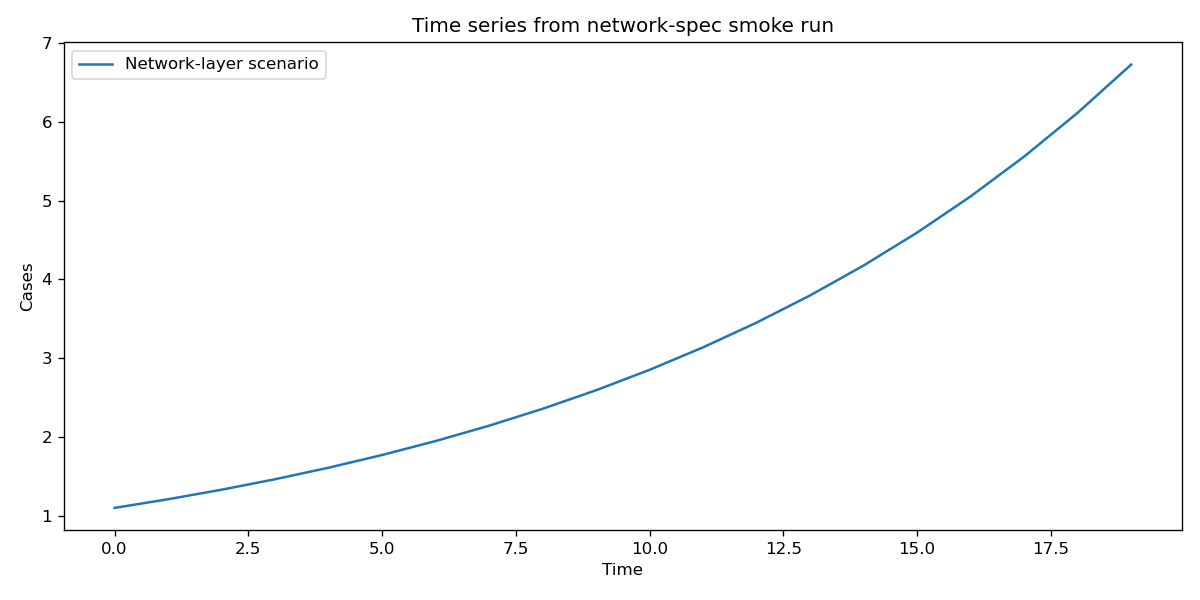

In [7]:
import io
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts.times, ts.values, label='Network-layer scenario')
ax.set_xlabel('Time')
ax.set_ylabel('Cases')
ax.set_title('Time series from network-spec smoke run')
ax.legend()
fig.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=120)
plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))
